In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [22]:
df = pd.read_csv("Unemployment in India.csv")

df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [24]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 768
Columns: 7


In [25]:
df.columns = df.columns.str.strip()

df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [26]:
df.isnull().sum()

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [27]:
df = df.dropna()

print(df.isnull().sum())

Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Area                                       0
dtype: int64


In [28]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

/tmp/ipykernel_633/3300519020.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [29]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [30]:
region_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

region_unemp.sort_values(ascending=False).head(10)

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


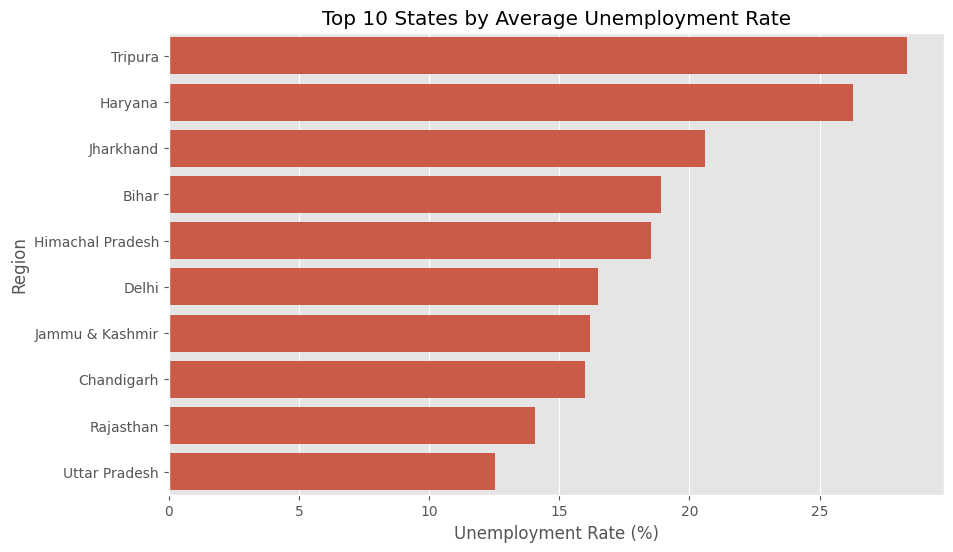

In [31]:
top10 = region_unemp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top10.values,y=top10.index)

plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Unemployment Rate (%)")
plt.show()

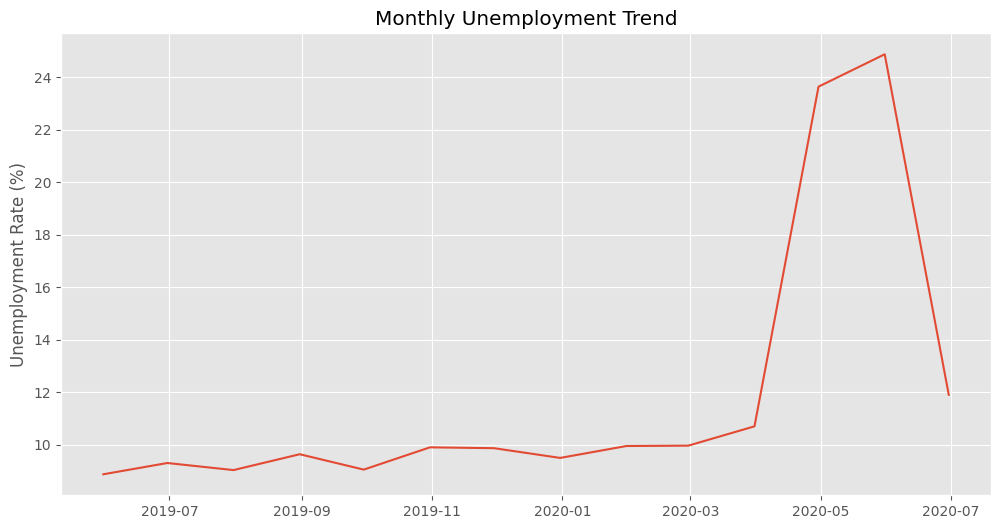

In [32]:
monthly = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))

plt.plot(monthly.index,
         monthly.values)

plt.title("Monthly Unemployment Trend")
plt.ylabel("Unemployment Rate (%)")

plt.show()

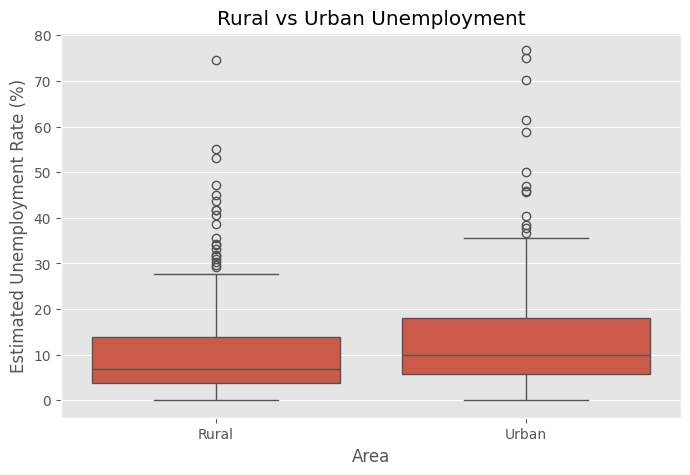

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Area',
    y='Estimated Unemployment Rate (%)',
    data=df
)

plt.title("Rural vs Urban Unemployment")
plt.show()

In [34]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [35]:
before_covid = df[df['Year']==2019]
during_covid = df[df['Year']==2020]

print(
    "Average Unemployment Before Covid:",
    before_covid['Estimated Unemployment Rate (%)'].mean()
)

print(
    "Average Unemployment During Covid:",
    during_covid['Estimated Unemployment Rate (%)'].mean()
)

Average Unemployment Before Covid: 9.399046511627906
Average Unemployment During Covid: 15.10158064516129


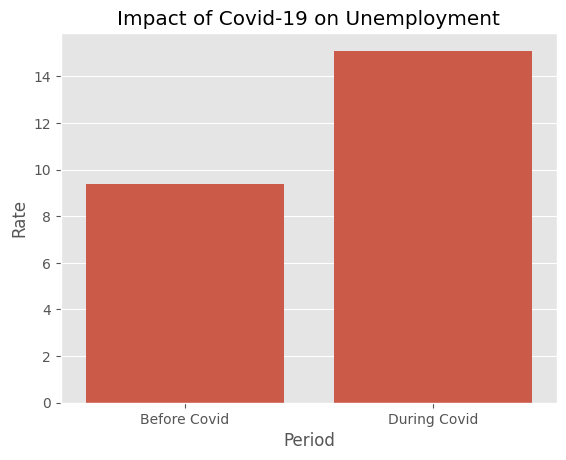

In [36]:
covid_compare = pd.DataFrame({
    'Period':['Before Covid','During Covid'],
    'Rate':[
        before_covid['Estimated Unemployment Rate (%)'].mean(),
        during_covid['Estimated Unemployment Rate (%)'].mean()
    ]
})

sns.barplot(
    data=covid_compare,
    x='Period',
    y='Rate'
)

plt.title("Impact of Covid-19 on Unemployment")
plt.show()

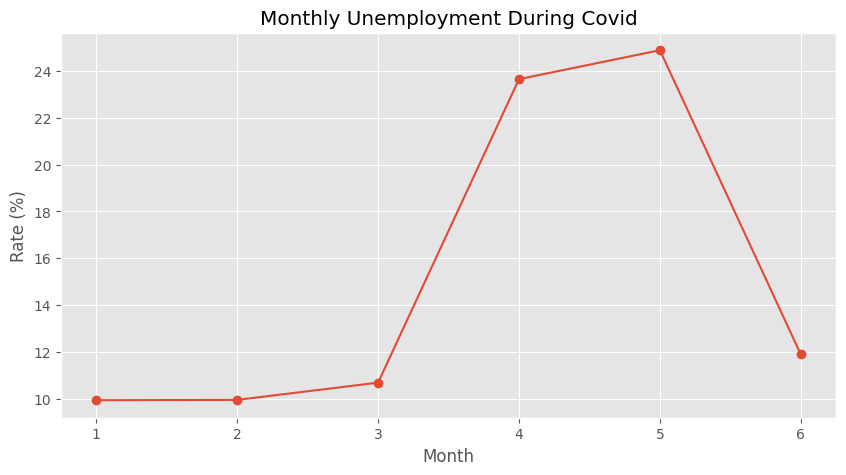

In [37]:
covid = df[df['Year']==2020]

monthly_covid = covid.groupby('Month')[
    'Estimated Unemployment Rate (%)'
].mean()

plt.figure(figsize=(10,5))

monthly_covid.plot(marker='o')

plt.title("Monthly Unemployment During Covid")
plt.ylabel("Rate (%)")
plt.show()

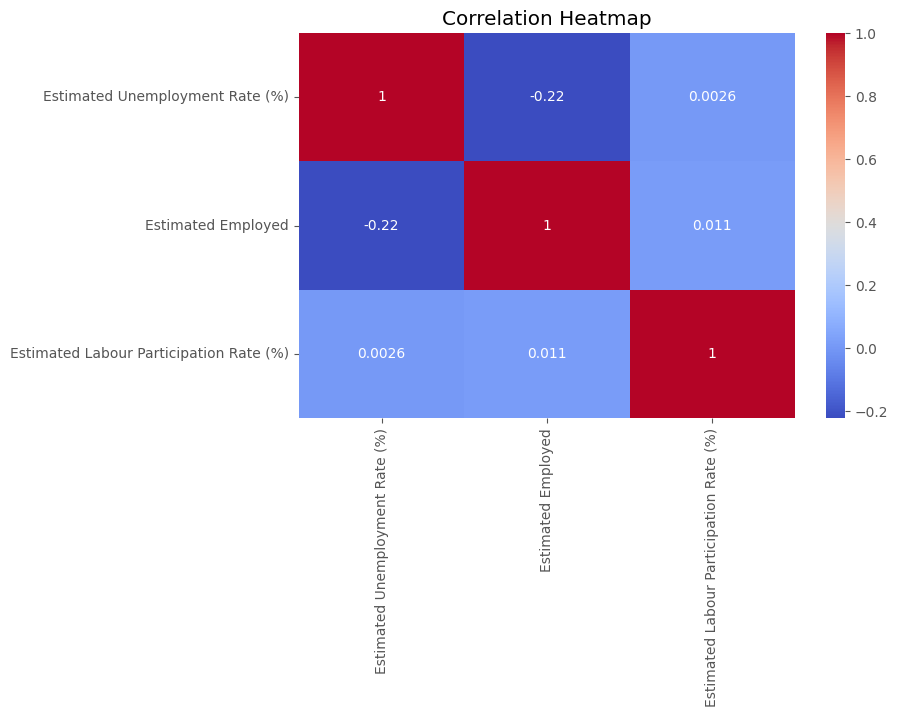

In [38]:
corr = df[[
'Estimated Unemployment Rate (%)',
'Estimated Employed',
'Estimated Labour Participation Rate (%)'
]].corr()

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()